<a href="https://colab.research.google.com/github/yusufsusin/TensorFlowIntro/blob/main/TensorFlow_Mis48B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Slide 1: Introduction to TensorFlow and Basic Setup

TensorFlow is an open-source machine learning framework developed by Google. It's widely used for building and training deep learning models across various domains, from image recognition to natural language processing.

In [ ]:
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


This code snippet imports the TensorFlow library, commonly aliased as `tf` for convenience. It also prints the installed TensorFlow version.

## Slide 2: Creating Tensors

Tensors are the fundamental data structures in TensorFlow. They are multi-dimensional arrays, similar to NumPy arrays, and form the basis of all computations in TensorFlow.

In [ ]:
# Create a constant tensor (its value cannot change)
tensor_a = tf.constant([[1, 2], [3, 4]], dtype=tf.float32)
print("Constant Tensor A:")
print(tensor_a)

# Create a variable tensor (its value can be updated, e.g., during model training)
tensor_b = tf.Variable([5, 6, 7], dtype=tf.float32)
print("\nVariable Tensor B:")
print(tensor_b)

# Create a tensor of ones
tensor_c = tf.ones(shape=(2, 2), dtype=tf.int32)
print("\nTensor of Ones (C):")
print(tensor_c)

Constant Tensor A:
tf.Tensor(
[[1. 2.]
 [3. 4.]], shape=(2, 2), dtype=float32)

Variable Tensor B:
<tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([5., 6., 7.], dtype=float32)>

Tensor of Ones (C):
tf.Tensor(
[[1 1]
 [1 1]], shape=(2, 2), dtype=int32)


Here, we demonstrate how to create different types of tensors: a constant tensor with fixed values, a variable tensor whose values can change, and a tensor filled with ones. The `dtype` argument specifies the data type of the tensor elements.

## Slide 3: Basic Tensor Operations

TensorFlow supports a wide range of mathematical operations on tensors, allowing you to perform complex computations efficiently. These operations are optimized for performance on various hardware, including GPUs.

In [ ]:
# Element-wise addition
tensor_x = tf.constant([10, 20], dtype=tf.float32)
tensor_y = tf.constant([1, 2], dtype=tf.float32)
tensor_sum = tensor_x + tensor_y  # or tf.add(tensor_x, tensor_y)
print("Tensor Sum (X + Y):")
print(tensor_sum)

# Element-wise multiplication
tensor_product = tensor_x * tensor_y  # or tf.multiply(tensor_x, tensor_y)
print("\nTensor Product (X * Y):")
print(tensor_product)

# Matrix multiplication (requires compatible shapes)
matrix_a = tf.constant([[1, 2], [3, 4]], dtype=tf.float32)
matrix_b = tf.constant([[5, 6], [7, 8]], dtype=tf.float32)
matrix_mul = tf.matmul(matrix_a, matrix_b)
print("\nMatrix Multiplication (A @ B):")
print(matrix_mul)

Tensor Sum (X + Y):
tf.Tensor([11. 22.], shape=(2,), dtype=float32)

Tensor Product (X * Y):
tf.Tensor([10. 40.], shape=(2,), dtype=float32)

Matrix Multiplication (A @ B):
tf.Tensor(
[[19. 22.]
 [43. 50.]], shape=(2, 2), dtype=float32)


These examples illustrate fundamental tensor operations: element-wise addition, element-wise multiplication, and matrix multiplication. These operations are crucial for building neural networks and other machine learning models.

## Slide 4: Building a Simple Linear Regression Model

Let's create a simple model to learn a linear relationship, specifically to predict `y = ax + b`. This is a classic 'Hello World' for machine learning.

In [ ]:
import numpy as np

# Generate synthetic data
X = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0], dtype=float)
y_true = np.array([0.5, 2.5, 4.5, 6.5, 8.5, 10.5], dtype=float)

# We'll try to learn the relationship y = 2x + 0.5
# In this case, a=2 and b=0.5

print("Input features (X):", X)
print("True labels (y_true):", y_true)

Input features (X): [0. 1. 2. 3. 4. 5.]
True labels (y_true): [ 0.5  2.5  4.5  6.5  8.5 10.5]


First, we generate some synthetic data `X` and `y_true` that follow a simple linear pattern. Our goal is for the model to learn the underlying coefficients (slope `a` and y-intercept `b`).

In [ ]:
# Define a simple sequential model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])

# Compile the model
model.compile(optimizer='sgd', loss='mean_squared_error')

print("Model Summary:")
model.summary()

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

We define a simple sequential Keras model with a single `Dense` layer. This layer has `units=1` because we're predicting a single output (`y`) and `input_shape=[1]` because each input `X` is a single number. We then `compile` the model, specifying the `optimizer` (Stochastic Gradient Descent) and the `loss` function (Mean Squared Error) to guide the learning process.

In [ ]:
# Train the model
history = model.fit(X, y_true, epochs=500, verbose=0)

print("Training finished. Let's see the learned weights:")
print("Weights (a):", model.layers[0].get_weights()[0][0][0])
print("Bias (b):", model.layers[0].get_weights()[1][0])

Training finished. Let's see the learned weights:
Weights (a): 2.0036285
Bias (b): 0.48712447


The `model.fit()` method trains the model using our input `X` and true labels `y_true` for a specified number of `epochs`. After training, we can inspect the learned `weights` (which correspond to 'a') and `bias` (which corresponds to 'b').

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predictions for X:
X: 0.0, True y: 0.5, Predicted y: 0.5
X: 1.0, True y: 2.5, Predicted y: 2.5
X: 2.0, True y: 4.5, Predicted y: 4.5
X: 3.0, True y: 6.5, Predicted y: 6.5
X: 4.0, True y: 8.5, Predicted y: 8.5
X: 5.0, True y: 10.5, Predicted y: 10.5


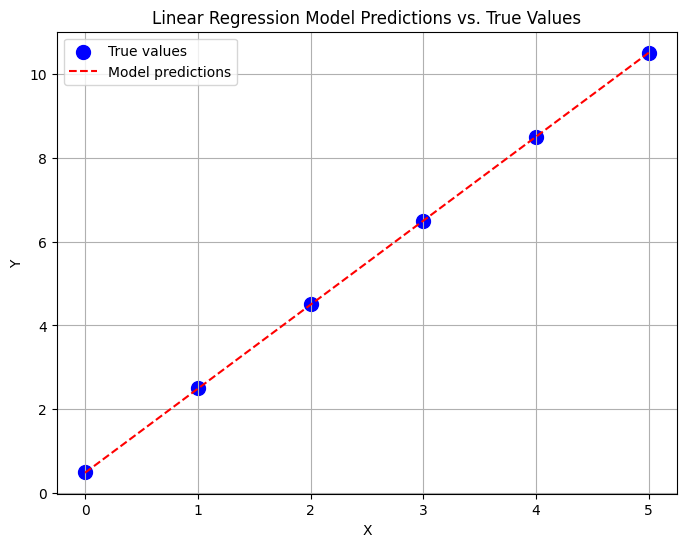

In [ ]:
import matplotlib.pyplot as plt

# Make a prediction with the trained model
y_pred = model.predict(X)

print("Predictions for X:")
for x_val, y_t, y_p in zip(X, y_true, y_pred):
    print(f"X: {x_val:.1f}, True y: {y_t:.1f}, Predicted y: {y_p[0]:.1f}")

# Visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(X, y_true, label='True values', color='blue', s=100)
plt.plot(X, y_pred, label='Model predictions', color='red', linestyle='--')
plt.title('Linear Regression Model Predictions vs. True Values')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

Finally, we use the trained model to make predictions on the input data `X` and visualize how well these predictions align with the original true values. You should see the red dashed line closely follow the blue dots, indicating the model has learned the linear relationship.